In [1]:
import torch

# LIBRI TTS
sd = torch.load("/home/blue2959/monotonic_tts/runs/monotonic_tts_local_support_emission_vctk_20260515-035636/checkpoints/last.pth")

# VCTK
# sd = torch.load("/home/blue2959/monotonic_tts/runs/monotonic_tts_local_support_emission_vctk_20260514-090732/checkpoints/last.pth")

In [2]:
import torch
from tts.config.stage1.data_config import DataConfig
from tts.tokenizer.text_tokenizer import TextTokenizer
from tts.data.tts_datafactory import TTSDataFactory  # 경로는 네 프로젝트 파일명에 맞게 조정
import random

max_samples = 5000
rng = random.Random(42)

# 1. data config / factory
config = DataConfig()
data_factory = TTSDataFactory(config)

# 2. tokenizer / labels
tokenizer = TextTokenizer()
labels = tokenizer.vocab_labels
n_vocab = len(labels)

sample_items = rng.sample(
    data_factory.train_items,
    k=min(max_samples, len(data_factory.train_items)),
)

print(f"Counting tokens from {len(sample_items)} train samples...")

token_counts = torch.zeros(n_vocab, dtype=torch.long)

for item in sample_items:
    ids = tokenizer(item.text).squeeze(0).long().cpu()
    ids = ids[(ids >= 0) & (ids < n_vocab)]

    token_counts.scatter_add_(
        dim=0,
        index=ids,
        src=torch.ones_like(ids, dtype=torch.long),
    )

min_count = 1
used_ids = (token_counts >= min_count).nonzero(as_tuple=False).squeeze(1)

weight = sd["model"]["text_embedder.out.weight"]
W = weight.detach().float().cpu()[:n_vocab]

W_used = W[used_ids]
labels_used = [
    f"{labels[i]} ({token_counts[i].item()})"
    for i in used_ids.tolist()
]

print("used tokens:", len(labels_used), "/", n_vocab)
print("W_used:", W_used.shape)

/home/blue2959/monotonic_tts/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Info] Parsed 149736 items from libritts
[Info] Filtering items by duration (1.5s ~ 25.0s)...


Filtering data: 100%|██████████| 149736/149736 [01:26<00:00, 1730.64it/s]


[Info] Filtered 18537 items. Remaining: 131199
[Info] Data split complete: 129888 train, 1311 valid
Counting tokens from 5000 train samples...
used tokens: 57 / 181
W_used: torch.Size([57, 256])


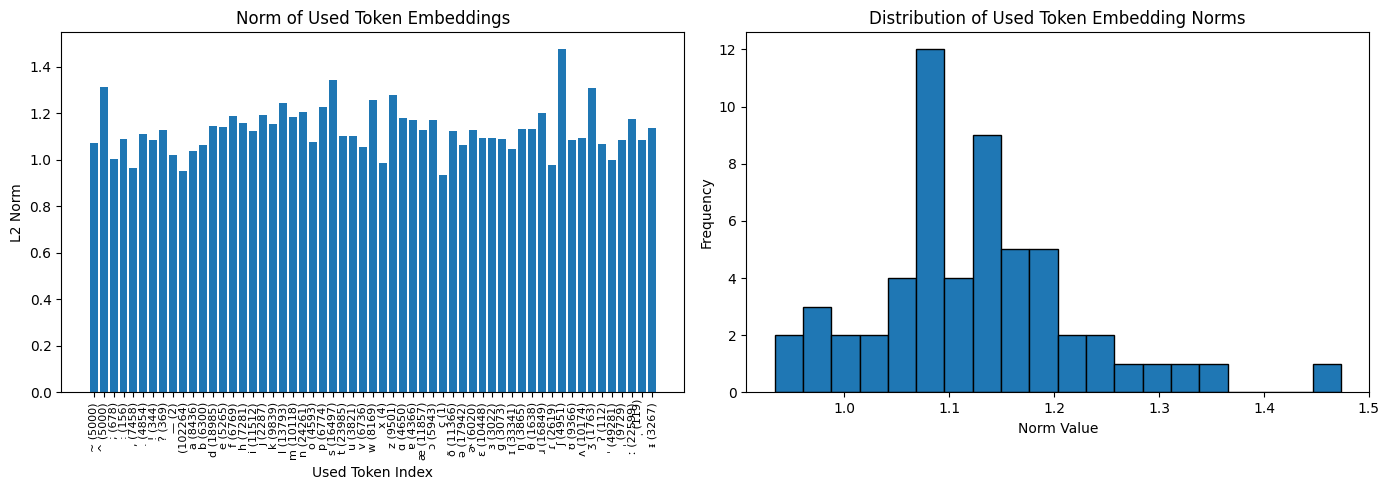

In [3]:
import torch
import matplotlib.pyplot as plt

# ----------------------------------
# used token embedding만 사용
# ----------------------------------
# W_used: (n_used, dim)
# labels_used: ["token (count)", ...]

norms = torch.norm(W_used, p=2, dim=1).detach().cpu().numpy()

# ----------------------------------
# 시각화
# ----------------------------------
plt.figure(figsize=(14, 5))

# 1. 막대 그래프
plt.subplot(1, 2, 1)
plt.bar(range(len(norms)), norms)
plt.title("Norm of Used Token Embeddings")
plt.xlabel("Used Token Index")
plt.ylabel("L2 Norm")

# x축 label이 너무 많으면 회전
plt.xticks(
    ticks=range(len(labels_used)),
    labels=labels_used,
    rotation=90,
    fontsize=8,
)

# 2. 히스토그램
plt.subplot(1, 2, 2)
plt.hist(norms, bins=20, edgecolor="black")
plt.title("Distribution of Used Token Embedding Norms")
plt.xlabel("Norm Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

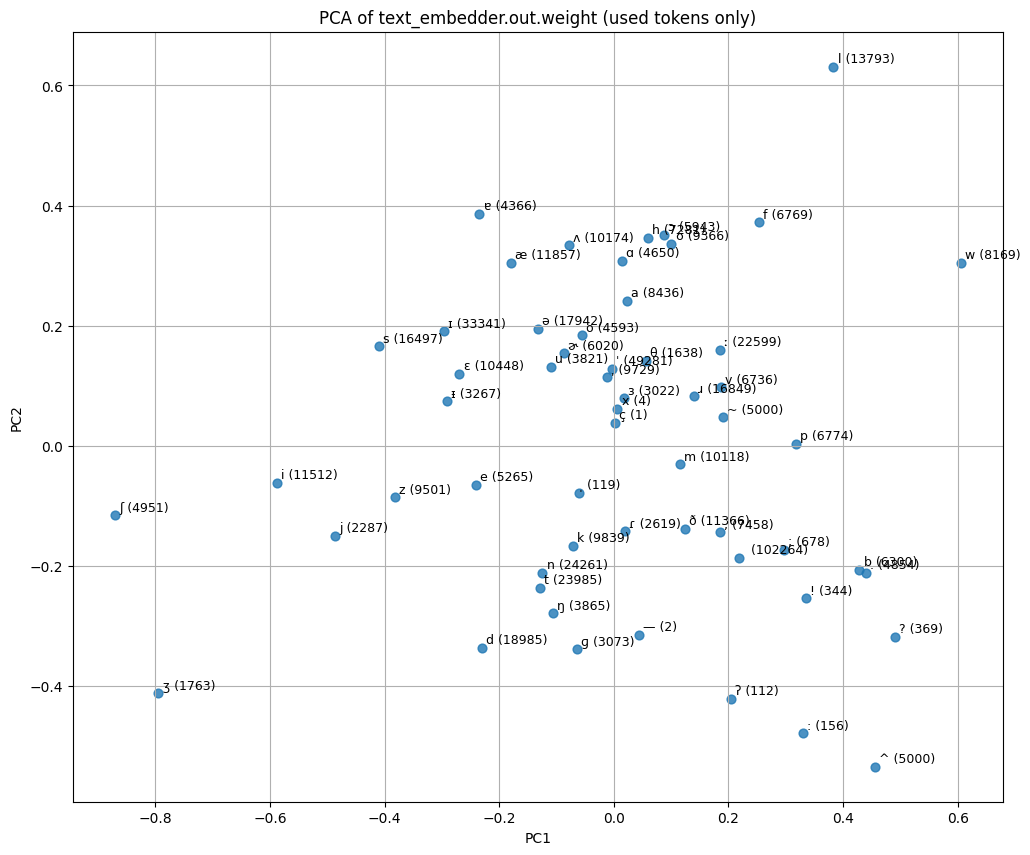

In [4]:
import torch
import matplotlib.pyplot as plt

# ----------------------------------
# 1. used embedding / labels 사용
# ----------------------------------
# W_used: (n_used, dim_out)
# labels_used: ["token (count)", ...]
W = W_used.detach().float().cpu()
labels = labels_used

# ----------------------------------
# 2. PCA
# ----------------------------------
W_centered = W - W.mean(dim=0, keepdim=True)

# 2개 주성분 추출
U, S, V = torch.pca_lowrank(W_centered, q=2)

# 2D projection
Z = W_centered @ V[:, :2]  # (n_used, 2)

# ----------------------------------
# 3. 시각화
# ----------------------------------
plt.figure(figsize=(12, 10))
plt.scatter(Z[:, 0], Z[:, 1], s=40, alpha=0.8)

for i, label in enumerate(labels):
    x = Z[i, 0].item()
    y = Z[i, 1].item()
    plt.annotate(
        label,
        (x, y),
        textcoords="offset points",
        xytext=(3, 3),
        fontsize=9,
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of text_embedder.out.weight (used tokens only)")
plt.grid(True)
plt.show()

q: 56
PC1 ratio: 0.0746048092842102
PC2 ratio: 0.0633118599653244
PC1+PC2 ratio: 0.1379166692495346


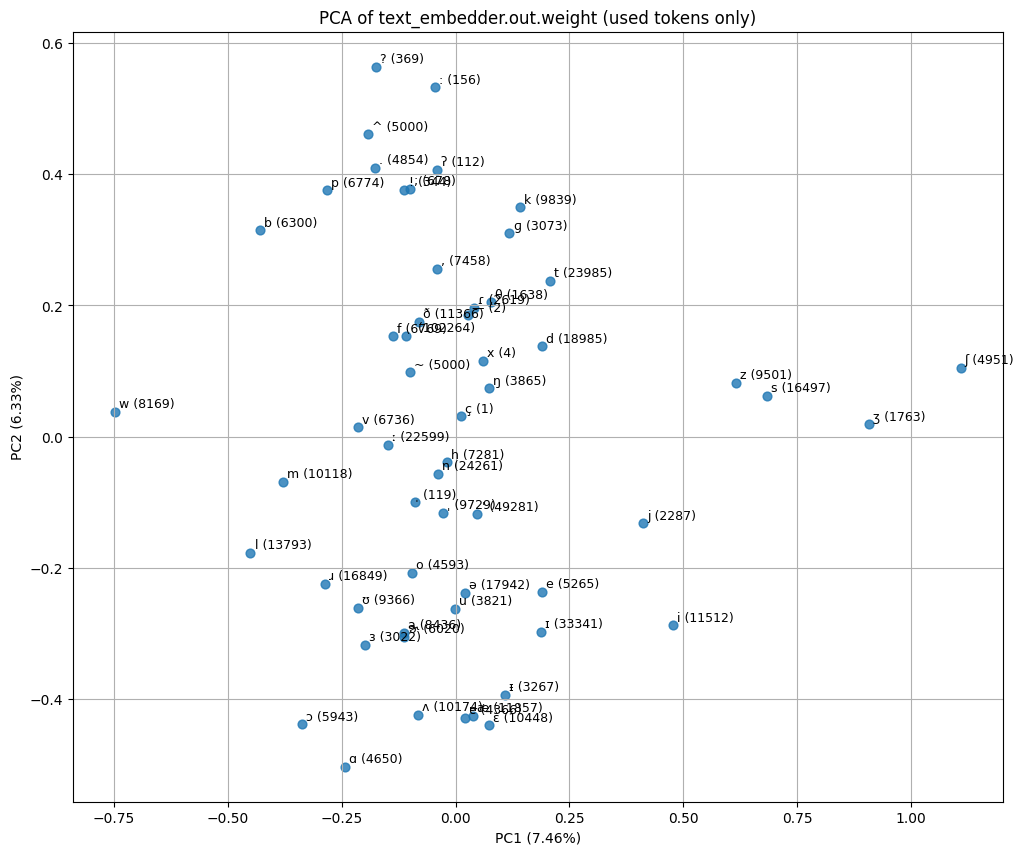

In [5]:
import torch
import matplotlib.pyplot as plt

# ----------------------------------
# 1. used token embedding / labels 사용
# ----------------------------------
# W_used: (n_used, dim_out)
# labels_used: ["token (count)", ...]
W = W_used.detach().float().cpu()
labels = labels_used

# ----------------------------------
# 2. PCA
# ----------------------------------
W_centered = W - W.mean(dim=0, keepdim=True)

# 전체 rank 기준 PCA
q = min(W_centered.shape[0] - 1, W_centered.shape[1])
U, S, V = torch.pca_lowrank(W_centered, q=q)

explained_var = S**2 / (W_centered.size(0) - 1)
explained_ratio = explained_var / explained_var.sum()

# 2D projection
Z = W_centered @ V[:, :2]

print("q:", q)
print("PC1 ratio:", explained_ratio[0].item())
print("PC2 ratio:", explained_ratio[1].item())
print("PC1+PC2 ratio:", explained_ratio[:2].sum().item())

# ----------------------------------
# 3. 시각화
# ----------------------------------
plt.figure(figsize=(12, 10))
plt.scatter(Z[:, 0], Z[:, 1], s=40, alpha=0.8)

for i, label in enumerate(labels):
    plt.annotate(
        label,
        (Z[i, 0].item(), Z[i, 1].item()),
        textcoords="offset points",
        xytext=(3, 3),
        fontsize=9,
    )

plt.xlabel(f"PC1 ({explained_ratio[0].item() * 100:.2f}%)")
plt.ylabel(f"PC2 ({explained_ratio[1].item() * 100:.2f}%)")
plt.title("PCA of text_embedder.out.weight (used tokens only)")
plt.grid(True)
plt.show()

In [6]:
import torch
import matplotlib.pyplot as plt

# ----------------------------------
# used token embedding만 사용
# ----------------------------------
# W_used: (n_used, dim_out)
# labels_used: ["token (count)", ...]
W = W_used.detach().float().cpu()
labels = labels_used

W_centered = W - W.mean(dim=0, keepdim=True)

# 가능한 최대 rank
q = min(W_centered.shape[0] - 1, W_centered.shape[1])

U, S, V = torch.pca_lowrank(W_centered, q=q)

explained_var = S**2 / (W_centered.size(0) - 1)
explained_ratio = explained_var / explained_var.sum()

print("used tokens:", len(labels))
print("q:", q)
print("PC1 ratio:", explained_ratio[0].item())
print("PC2 ratio:", explained_ratio[1].item())
print("PC1+PC2 ratio:", explained_ratio[:2].sum().item())

if q >= 5:
    print("PC1~PC5 ratio:", explained_ratio[:5].sum().item())

if q >= 10:
    print("PC1~PC10 ratio:", explained_ratio[:10].sum().item())

used tokens: 52
q: 51
PC1 ratio: 0.10319218784570694
PC2 ratio: 0.07951881736516953
PC1+PC2 ratio: 0.18271100521087646
PC1~PC5 ratio: 0.36478543281555176
PC1~PC10 ratio: 0.5438461303710938


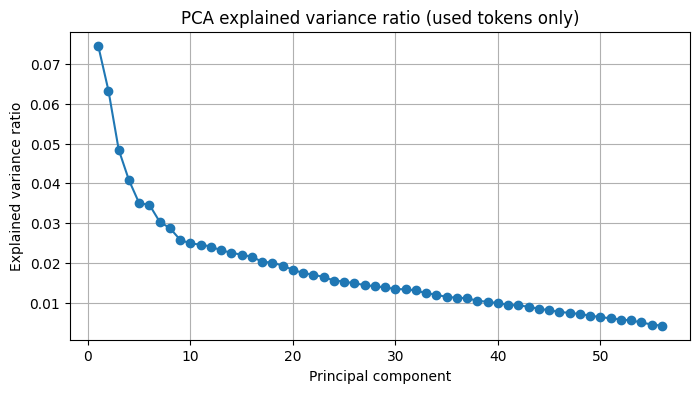

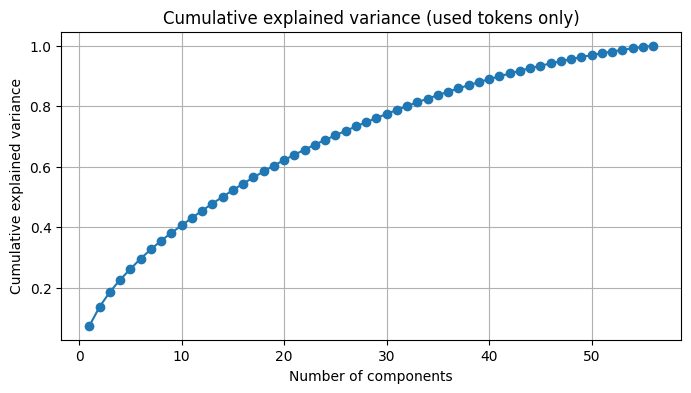

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(
    torch.arange(1, q + 1),
    explained_ratio.cpu().numpy(),
    marker="o",
)
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA explained variance ratio (used tokens only)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(
    torch.arange(1, q + 1),
    explained_ratio.cumsum(0).cpu().numpy(),
    marker="o",
)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative explained variance (used tokens only)")
plt.grid(True)
plt.show()

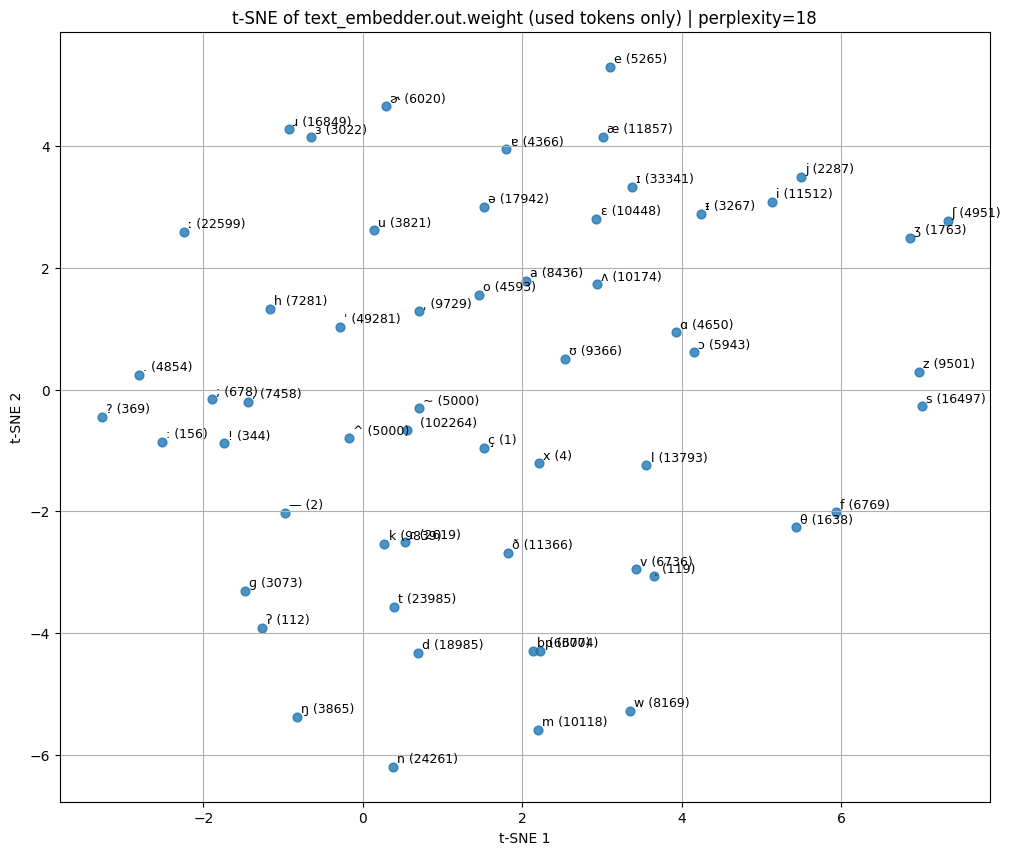

In [7]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import torch

# ----------------------------------
# 1. used token embedding만 사용
# ----------------------------------
# W_used: (n_used, dim_out)
# labels_used: ["token (count)", ...]
W = W_used.detach().float().cpu()
labels = labels_used
n_used = W.size(0)

# ----------------------------------
# 2. PCA preprocessing
# ----------------------------------
W_centered = W - W.mean(dim=0, keepdim=True)

q = min(n_used - 1, W_centered.shape[1], 50)
U, S, V = torch.pca_lowrank(W_centered, q=q)

W_pca = W_centered @ V[:, :q]  # (n_used, q)

# ----------------------------------
# 3. t-SNE
# ----------------------------------
X = W_pca.numpy()

# perplexity는 sample 수보다 작아야 함
perplexity = min(30, max(2, (n_used - 1) // 3))

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate="auto",
    init="pca",
    random_state=42,
    max_iter=2000,
)

Z_tsne = tsne.fit_transform(X)

# ----------------------------------
# 4. 시각화
# ----------------------------------
plt.figure(figsize=(12, 10))
plt.scatter(Z_tsne[:, 0], Z_tsne[:, 1], s=40, alpha=0.8)

for i, label in enumerate(labels):
    plt.annotate(
        label,
        (Z_tsne[i, 0], Z_tsne[i, 1]),
        textcoords="offset points",
        xytext=(3, 3),
        fontsize=9,
    )

plt.title(
    f"t-SNE of text_embedder.out.weight "
    + f"(used tokens only) | perplexity={perplexity}"
)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True)
plt.show()

/home/blue2959/monotonic_tts/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


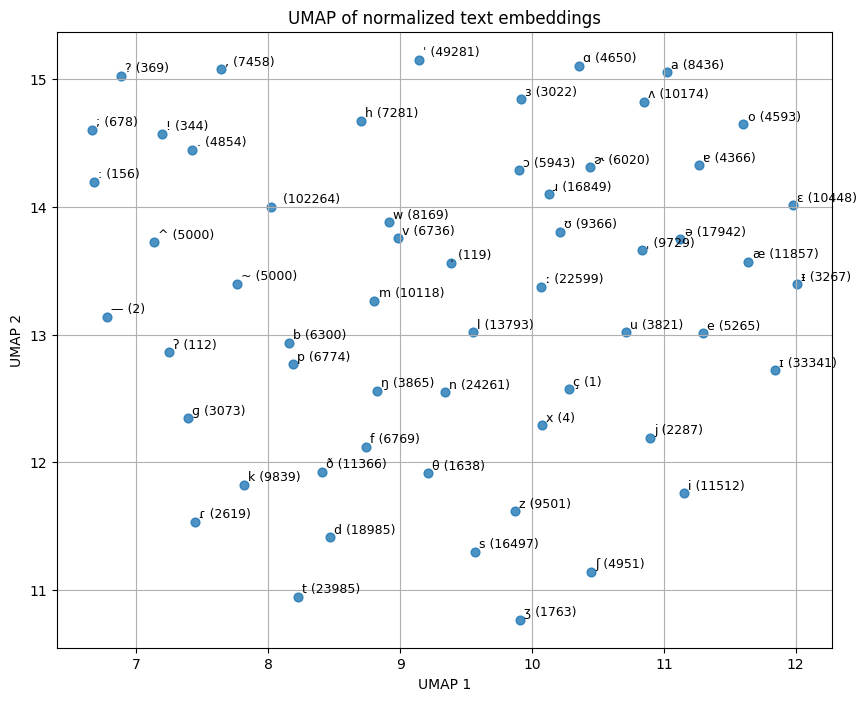

In [8]:
import umap
import torch.nn.functional as F
import matplotlib.pyplot as plt

W = W_used.detach().float().cpu()
labels = labels_used
n_used = W.size(0)

W_norm = F.normalize(W, p=2, dim=1)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=min(30, max(5, n_used // 2)),
    min_dist=0.4,          # 높이면 덜 뭉치고 덜 과장됨
    metric="cosine",
    random_state=42,
)

Z_umap = reducer.fit_transform(W_norm.numpy())

plt.figure(figsize=(10, 8))
plt.scatter(Z_umap[:, 0], Z_umap[:, 1], s=40, alpha=0.8)

for i, label in enumerate(labels):
    plt.annotate(
        label,
        (Z_umap[i, 0], Z_umap[i, 1]),
        textcoords="offset points",
        xytext=(3, 3),
        fontsize=9,
    )

plt.title("UMAP of normalized text embeddings")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.show()